## Comparação: Classificação Humana vs Gemini 3.0 Flash

Este notebook compara os critérios de inclusão classificados manualmente (`articles-2.json`) com os scores gerados pelo modelo GEMINI (`result.json`), gerando um arquivo CSV consolidado.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import json
import pandas as pd
import os


ARTICLES_PATH = "/home/jelson/Projetos/SE4AI-MLOps-Mapping/llm-sm-selection/data/articles_2.json"
RESULT_PATH   = "/home/jelson/Projetos/SE4AI-MLOps-Mapping/llm-sm-selection/results/gemini-3-flash-base-2/result.json"

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Pré-processamento do `articles.json`

Extração das colunas base e derivação dos critérios de inclusão humanos (CI1, CI2, CI3).

> **Lógica:** O campo `Inclusão` indica até qual critério o artigo foi incluído.
> Caso o campo `Inclusão` seja nulo, todos os CIs são 0.

In [5]:
with open(ARTICLES_PATH, 'r', encoding='utf-8') as f:
    articles = json.load(f)[:100]

with open(RESULT_PATH, 'r', encoding='utf-8') as f:
    results = json.load(f)

print(f'articles.json: {len(articles)} registros')
print(f'result.json:   {len(results)} registros')

articles.json: 100 registros
result.json:   100 registros


In [6]:
CRITERIOS_ORDEM = ['CI1', 'CI2', 'CI3']

def extrair_cis_humanos(inclusao_val):
    """Retorna dict com CI1, CI2, CI3 (0 ou 1) baseado no campo Inclusão."""
    result = {'CI1': False, 'CI2': False, 'CI3': False}
    if not inclusao_val:
        return result
    inclusao_val = str(inclusao_val).strip().upper()
    for ci in CRITERIOS_ORDEM:
        if ci in inclusao_val:
            result[ci] = True
    return result

rows_articles = []
for art in articles:
    cis = extrair_cis_humanos(art.get('Inclusão'))
    rows_articles.append({
        'DOI':    art.get('DOI'),
        'ISBNs':  art.get('ISBNs'),
        'ISSN':   art.get('ISSN'),
        'Título': art.get('Título'),
        'Autor':  art.get('Autor'),
        'Abstract': art.get('Abstract'),
        'Ano':    art.get('Ano'),
        'CI1':    cis['CI1'],
        'CI2':    cis['CI2'],
        'CI3':    cis['CI3'],
    })

df_articles = pd.DataFrame(rows_articles)
df_articles['DOI'] = df_articles['DOI'].str.strip()
print(f'Shape: {df_articles.shape}')
df_articles.head()

Shape: (100, 10)


,DOI,ISBNs,ISSN,Título,Autor,Abstract,Ano,CI1,CI2,CI3
0,10.1145/3549036.3562059,978-1-4503-9458-1,None,QAI4ASE: Quantum artificial intelligence for a...,"De Vincentiis, Mirko; Cassano, Fabio; Pagano, ...","Nowadays, the size and complexity of the autom...",2022,False,False,False
1,NaN,978-1-4503-8307-3,None,Software Engineering Methods for Responsible A...,"Islam, Zahoor Ul",In order to ensure responsible Artificial inte...,2021,True,True,True
2,10.1109/ICSE-NIER66352.2025.00009,9798331537111,None,Digital Twins for Software Engineering Processes,"Kimmel, Robin; Michael, Judith; Wortmann, Andr...",Digital twins promise a better understanding a...,2025,False,False,False
3,10.1145/3613372.3614199,9798400707872,None,Hyacinth macaw: a project-based learning progr...,"Fontão, Awdren; Matsubara, Edson; Mongelli, He...",Software Engineering for Artificial Intelligen...,2023,True,True,True
4,NaN,978-1-4503-9275-4,None,CAIN '22: Proceedings of the 1st International...,NaN,The aim of the conference is to bring together...,2022,False,False,False


## 2. Pré-processamento do `result.json` (GEMINI)

Extração dos scores IC1, IC2, IC3 gerados pelo modelo.

In [7]:
def extrair_score(inclusion_results, criterion):
    """Busca o score de um critério específico na lista inclusion_results."""
    for item in inclusion_results:
        if item.get('criterion', '').upper() == criterion.upper():
            return item.get('decision')
    return None

rows_gemini = []
for res in results:
    meta = res.get('article_metadata', {})
    inc  = res.get('inclusion_results', [])
    doi  = meta.get('DOI', '')
    rows_gemini.append({
        'DOI':         doi.strip() if doi else doi,
        'Título':      meta['title'],
        'Autor':       meta['author'],
        'Ano':         meta['year'],
        'CI1_GEMINI':  extrair_score(inc, 'CI1'),
        'CI2_GEMINI':  extrair_score(inc, 'CI2'),
        'CI3_GEMINI':  extrair_score(inc, 'CI3'),
    })

df_gemini = pd.DataFrame(rows_gemini)
mean_cols = ['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
print(f'Shape: {df_gemini.shape}')
df_gemini.head()

Shape: (100, 7)


,DOI,Título,Autor,Ano,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI
0,10.1145/3549036.3562059,QAI4ASE: Quantum artificial intelligence for a...,"De Vincentiis, Mirko; Cassano, Fabio; Pagano, ...",2022,NO,NO,NO
1,NaN,Software Engineering Methods for Responsible A...,"Islam, Zahoor Ul",2021,YES,YES,NO
2,10.1109/ICSE-NIER66352.2025.00009,Digital Twins for Software Engineering Processes,"Kimmel, Robin; Michael, Judith; Wortmann, Andr...",2025,NO,NO,NO
3,10.1145/3613372.3614199,Hyacinth macaw: a project-based learning progr...,"Fontão, Awdren; Matsubara, Edson; Mongelli, He...",2023,YES,NO,NO
4,NaN,CAIN '22: Proceedings of the 1st International...,NaN,2022,YES,NO,YES


## 3. Merge dos DataFrames

In [8]:
df_merged = df_articles.merge(df_gemini, on=['Título', 'Autor', 'Ano'], how='left')

# Selecionar e ordenar colunas finais
cols_final = ['ISBNs', 'ISSN', 'Título', 'Abstract', 'Autor', 'Ano',
              'CI1', 'CI2', 'CI3',
              'CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
df_final = df_merged[cols_final]

print(f'Total de artigos no CSV final: {len(df_final)}')
print(f'Artigos sem match GEMINI: {df_final["CI1_GEMINI"].isna().sum()}')
df_final.head(10)

Total de artigos no CSV final: 100
Artigos sem match GEMINI: 0


,ISBNs,ISSN,Título,Abstract,Autor,Ano,CI1,CI2,CI3,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI
0,978-1-4503-9458-1,None,QAI4ASE: Quantum artificial intelligence for a...,"Nowadays, the size and complexity of the autom...","De Vincentiis, Mirko; Cassano, Fabio; Pagano, ...",2022,False,False,False,NO,NO,NO
1,978-1-4503-8307-3,None,Software Engineering Methods for Responsible A...,In order to ensure responsible Artificial inte...,"Islam, Zahoor Ul",2021,True,True,True,YES,YES,NO
2,9798331537111,None,Digital Twins for Software Engineering Processes,Digital twins promise a better understanding a...,"Kimmel, Robin; Michael, Judith; Wortmann, Andr...",2025,False,False,False,NO,NO,NO
3,9798400707872,None,Hyacinth macaw: a project-based learning progr...,Software Engineering for Artificial Intelligen...,"Fontão, Awdren; Matsubara, Edson; Mongelli, He...",2023,True,True,True,YES,NO,NO
4,978-1-4503-9275-4,None,CAIN '22: Proceedings of the 1st International...,The aim of the conference is to bring together...,NaN,2022,False,False,False,YES,NO,YES
5,9798400715136,None,A Novel Artificial Intelligence Voice Electron...,"Nowadays, the global digital transformation of...","Xie, Weiming; Yao, Zhaomin; Bai, Xiaozhou; Mai...",2025,False,False,False,NO,NO,NO
6,9798400721021,None,COL-SAI: COllaboration and Learning through Sy...,The COllaboration and Learning through Symbiot...,"Calvano, Miriana; Curci, Antonio; Cantone, And...",2025,False,False,False,NO,NO,NO
7,9798400706585,None,Software Engineering and Gender: A Tutorial,Software runs the world and should provide equ...,"Jaccheri, Letizia; Duc, Anh Nguyen",2024,False,False,False,NO,NO,NO
8,9798400717925,None,A License Management System for Collaborative ...,The AI marketplace ecosystem accelerates multi...,"Daliparthi, Venkata Satya Sai Ajay; Tutschku, ...",2025,True,True,True,YES,NO,NO
9,9798400717017,None,Surfing the AI Wave in Software Engineering: O...,"The diffusion of generative AI, specifically L...","Novielli, Nicole",2024,False,False,False,NO,NO,YES


## 4. Análise Exploratória Rápida

In [9]:
threshold = 'YES'

for i in range(1, 4):
    real_col = f'CI{i}'
    gemini_col = f'CI{i}_GEMINI'
    result_col = f'RESULT_CI{i}'
    
    df_final[result_col] = (df_final[real_col] == (df_final[gemini_col] == threshold)).map({True: 'C', False: 'E'})

df_final.head(10)

,ISBNs,ISSN,Título,Abstract,Autor,Ano,CI1,CI2,CI3,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI,RESULT_CI1,RESULT_CI2,RESULT_CI3
0,978-1-4503-9458-1,None,QAI4ASE: Quantum artificial intelligence for a...,"Nowadays, the size and complexity of the autom...","De Vincentiis, Mirko; Cassano, Fabio; Pagano, ...",2022,False,False,False,NO,NO,NO,C,C,C
1,978-1-4503-8307-3,None,Software Engineering Methods for Responsible A...,In order to ensure responsible Artificial inte...,"Islam, Zahoor Ul",2021,True,True,True,YES,YES,NO,C,C,E
2,9798331537111,None,Digital Twins for Software Engineering Processes,Digital twins promise a better understanding a...,"Kimmel, Robin; Michael, Judith; Wortmann, Andr...",2025,False,False,False,NO,NO,NO,C,C,C
3,9798400707872,None,Hyacinth macaw: a project-based learning progr...,Software Engineering for Artificial Intelligen...,"Fontão, Awdren; Matsubara, Edson; Mongelli, He...",2023,True,True,True,YES,NO,NO,C,E,E
4,978-1-4503-9275-4,None,CAIN '22: Proceedings of the 1st International...,The aim of the conference is to bring together...,NaN,2022,False,False,False,YES,NO,YES,E,C,E
5,9798400715136,None,A Novel Artificial Intelligence Voice Electron...,"Nowadays, the global digital transformation of...","Xie, Weiming; Yao, Zhaomin; Bai, Xiaozhou; Mai...",2025,False,False,False,NO,NO,NO,C,C,C
6,9798400721021,None,COL-SAI: COllaboration and Learning through Sy...,The COllaboration and Learning through Symbiot...,"Calvano, Miriana; Curci, Antonio; Cantone, And...",2025,False,False,False,NO,NO,NO,C,C,C
7,9798400706585,None,Software Engineering and Gender: A Tutorial,Software runs the world and should provide equ...,"Jaccheri, Letizia; Duc, Anh Nguyen",2024,False,False,False,NO,NO,NO,C,C,C
8,9798400717925,None,A License Management System for Collaborative ...,The AI marketplace ecosystem accelerates multi...,"Daliparthi, Venkata Satya Sai Ajay; Tutschku, ...",2025,True,True,True,YES,NO,NO,C,E,E
9,9798400717017,None,Surfing the AI Wave in Software Engineering: O...,"The diffusion of generative AI, specifically L...","Novielli, Nicole",2024,False,False,False,NO,NO,YES,C,C,E


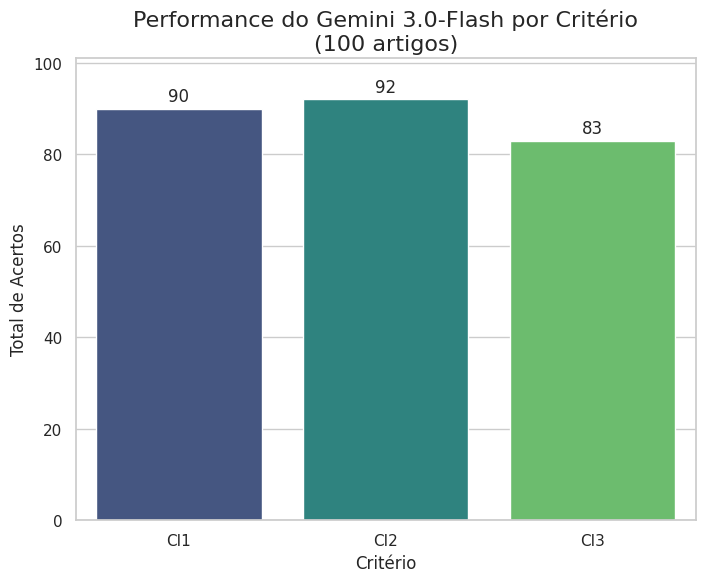

In [10]:
resultados = []
for i in range(1, 4):
    total_acertos = (df_final[f'RESULT_CI{i}'] == 'C').sum()
    resultados.append({'Critério': f'CI{i}', 'Acertos': total_acertos})

df_plot = pd.DataFrame(resultados)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

grafico = sns.barplot(
    x='Critério', 
    y='Acertos', 
    data=df_plot, 
    palette='viridis',
    hue='Critério',
    legend=False 
)

for p in grafico.patches:
    grafico.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Performance do Gemini 3.0-Flash por Critério\n(100 artigos)', fontsize=16)
plt.ylabel('Total de Acertos')
plt.ylim(0, len(df_final) + 1)
plt.show()

In [11]:
df_final[['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']].apply(pd.Series.value_counts)

,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI
NO,80.0,88.0,79
UNCLEAR,NaN,NaN,1
YES,20.0,12.0,20


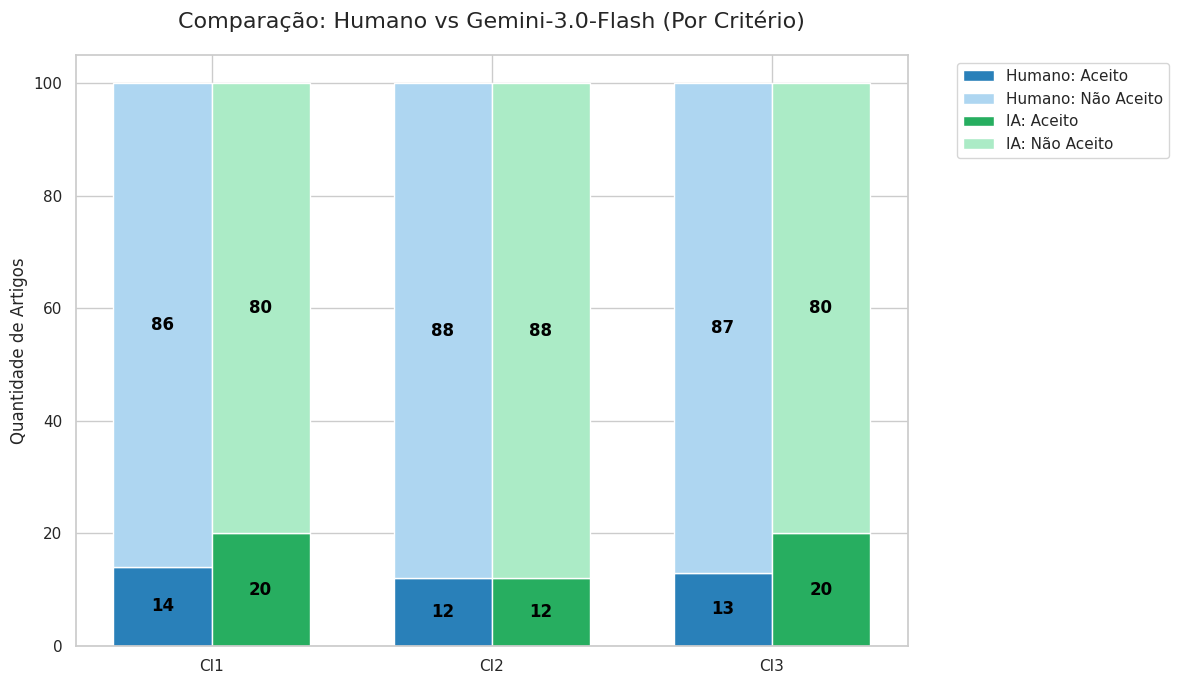

In [12]:
dados = []
threshold = "YES"

for i in range(1, 4):
    h_aceitos = df_final[f'CI{i}'].sum()
    h_nao_aceitos = len(df_final) - h_aceitos
    
    ia_aceitos = (df_final[f'CI{i}_GEMINI'] == threshold).sum()
    ia_nao_aceitos = len(df_final) - ia_aceitos
    
    dados.append({
        'Critério': f'CI{i}',
        'Humano_Aceito': h_aceitos,
        'Humano_Não_Aceito': h_nao_aceitos,
        'IA_Aceito': ia_aceitos,
        'IA_Não_Aceito': ia_nao_aceitos
    })

df_comp = pd.DataFrame(dados).set_index('Critério')

fig, ax = plt.subplots(figsize=(12, 7))

width = 0.35
x = range(len(df_comp))

ax.bar([i - width/2 for i in x], df_comp['Humano_Aceito'], width, label='Humano: Aceito', color='#2980b9')
ax.bar([i - width/2 for i in x], df_comp['Humano_Não_Aceito'], width, bottom=df_comp['Humano_Aceito'], 
       label='Humano: Não Aceito', color='#aed6f1')

ax.bar([i + width/2 for i in x], df_comp['IA_Aceito'], width, label='IA: Aceito', color='#27ae60')
ax.bar([i + width/2 for i in x], df_comp['IA_Não_Aceito'], width, bottom=df_comp['IA_Aceito'], 
       label='IA: Não Aceito', color='#abebc6')

ax.set_title('Comparação: Humano vs Gemini-3.0-Flash (Por Critério)', fontsize=16, pad=20)
ax.set_ylabel('Quantidade de Artigos')
ax.set_xticks(x)
ax.set_xticklabels(df_comp.index)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for i, rect in enumerate(ax.patches):
    height = rect.get_height()
    if height > 0:
        ax.text(rect.get_x() + rect.get_width()/2., rect.get_y() + height/2.,
                f'{int(height)}', ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

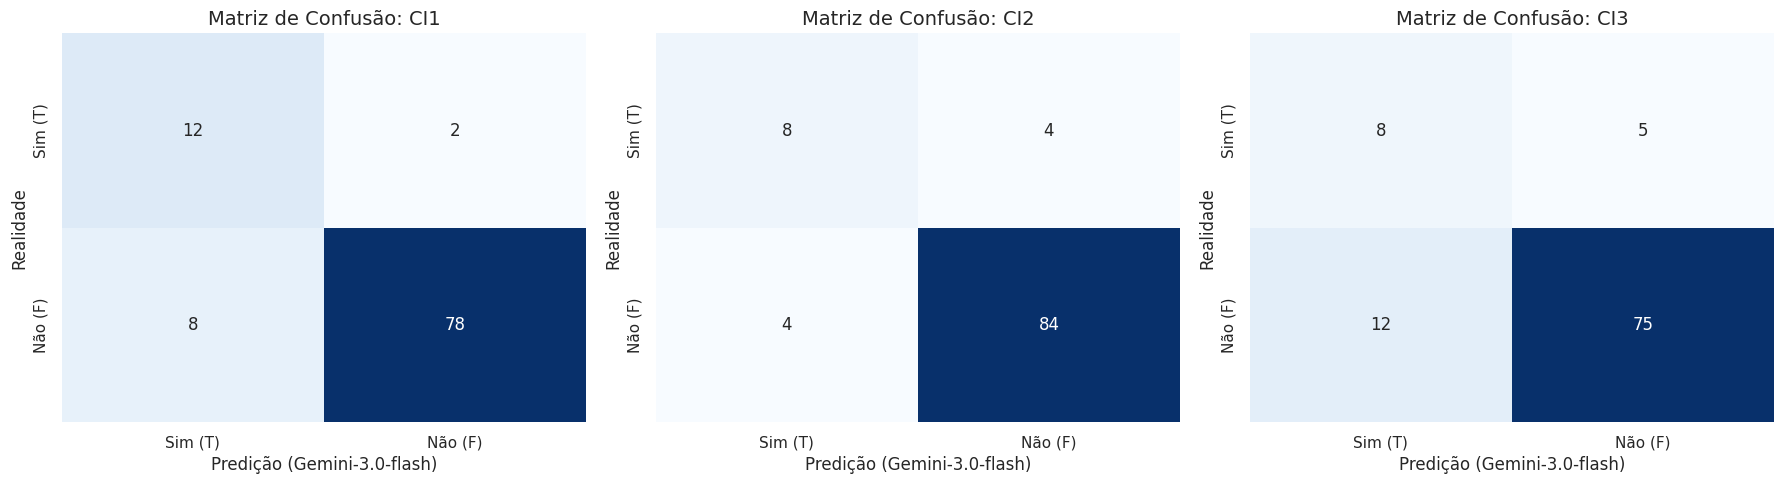

In [13]:
threshold = "YES"
criterios = ['CI1', 'CI2', 'CI3']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, crit in enumerate(criterios):
    y_true = df_final[crit]
    y_pred = df_final[f'{crit}_GEMINI'] == threshold
    cm = confusion_matrix(y_true, y_pred, labels=[True, False])
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Sim (T)', 'Não (F)'],
        yticklabels=['Sim (T)', 'Não (F)'],
        cbar=False 
    )
    
    axes[i].set_title(f'Matriz de Confusão: {crit}', fontsize=14)
    axes[i].set_xlabel('Predição (Gemini-3.0-flash)')
    axes[i].set_ylabel('Realidade')

plt.tight_layout()
plt.show()

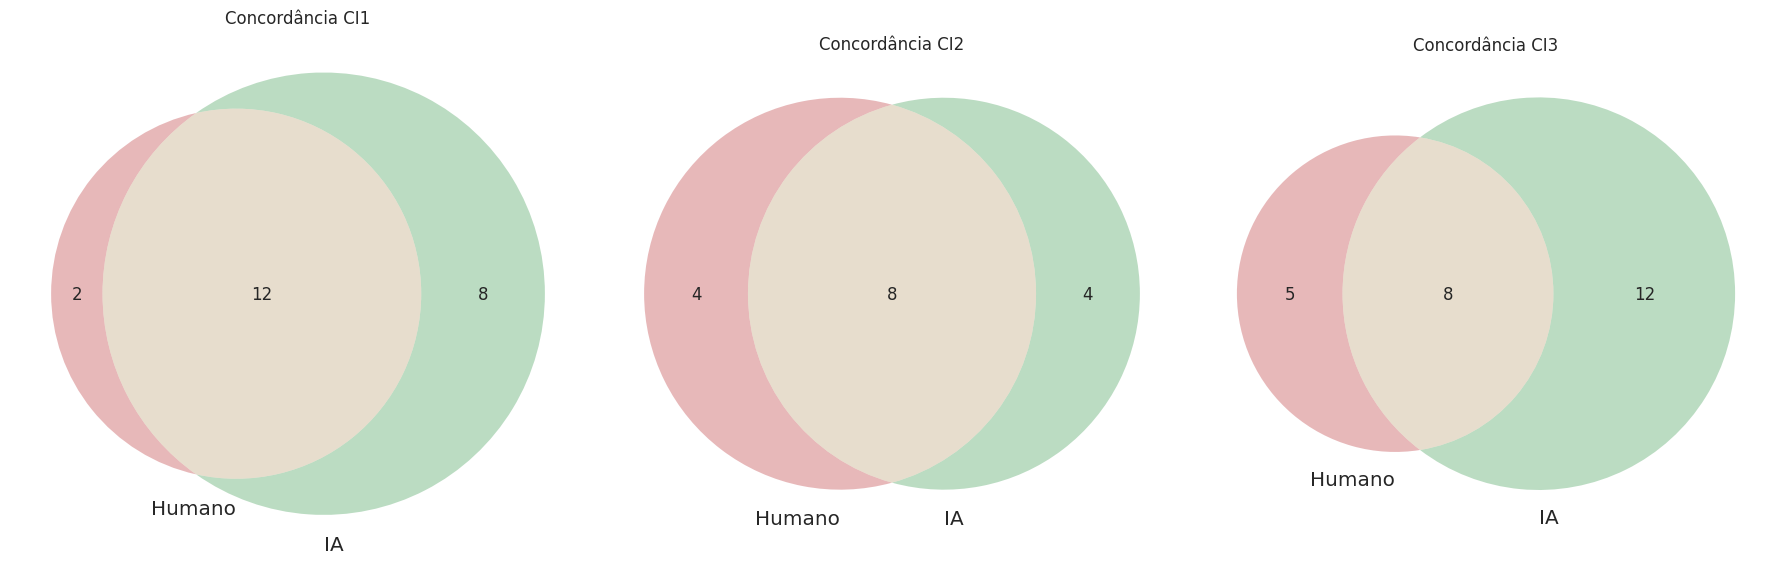

In [14]:
from matplotlib_venn import venn2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(1, 4):
    real = df_final[f'CI{i}']
    pred = df_final[f'CI{i}_GEMINI'] == "YES"
    
    # Cálculos para o Venn
    so_humano = ((real == True) & (pred == False)).sum()
    so_ia = ((real == False) & (pred == True)).sum()
    ambos = ((real == True) & (pred == True)).sum()
    
    venn2(subsets=(so_humano, so_ia, ambos), 
          set_labels=('Humano', 'IA'), 
          ax=axes[i-1])
    axes[i-1].set_title(f"Concordância CI{i}")

plt.tight_layout()
plt.show()

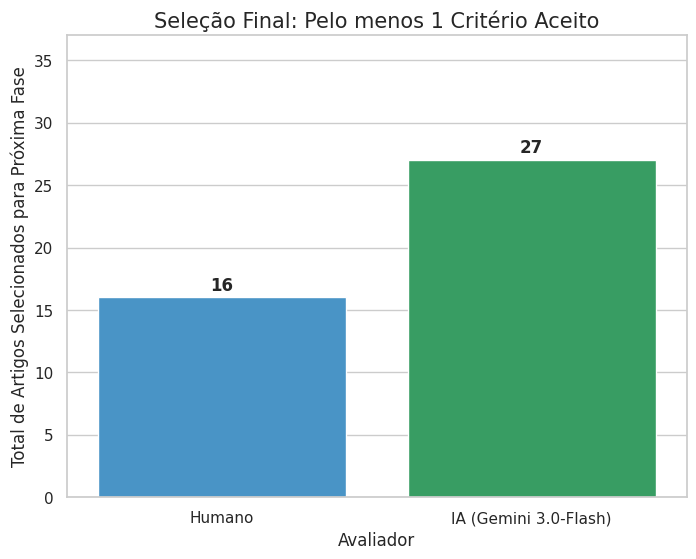

In [15]:
threshold = "YES"
df_final['INCLUSAO_HUMANO'] = df_final[['CI1', 'CI2', 'CI3']].any(axis=1)
cols_gemini = ['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
df_final['INCLUSAO_IA'] = (df_final[cols_gemini] == threshold).any(axis=1)

total_humano = df_final['INCLUSAO_HUMANO'].sum()
total_ia = df_final['INCLUSAO_IA'].sum()

df_resumo_final = pd.DataFrame({
    'Avaliador': ['Humano', 'IA (Gemini 3.0-Flash)'],
    'Artigos Incluídos': [total_humano, total_ia]
})

sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 6))

grafico = sns.barplot(
    x='Avaliador', 
    y='Artigos Incluídos', 
    data=df_resumo_final, 
    hue='Avaliador', 
    palette=['#3498db', '#27ae60'],
    legend=False
)

for p in grafico.patches:
    grafico.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

plt.title('Seleção Final: Pelo menos 1 Critério Aceito', fontsize=15)
plt.ylabel('Total de Artigos Selecionados para Próxima Fase')
plt.ylim(0, max(total_humano, total_ia) + 10)
plt.show()

--- Totais de Seleção Final ---
Apenas Humano: 2
Apenas IA: 13
Ambos (Interseção): 14
------------------------------


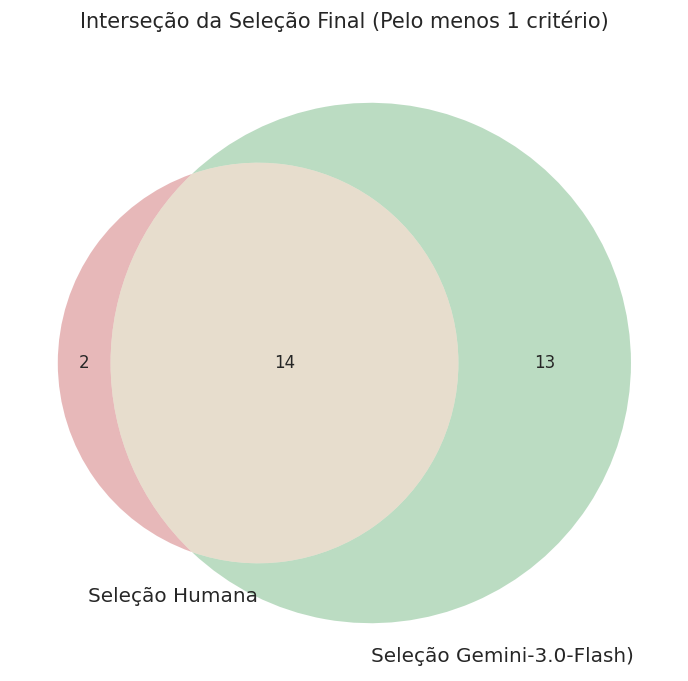

In [16]:
threshold = "YES"
df = df_final.copy()

df['INCLUSAO_HUMANO'] = df[['CI1', 'CI2', 'CI3']].any(axis=1)
cols_gemini = ['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
df['INCLUSAO_IA'] = (df[cols_gemini] >= threshold).any(axis=1)
so_humano = ((df['INCLUSAO_HUMANO'] == True) & (df['INCLUSAO_IA'] == False)).sum()
so_ia = ((df['INCLUSAO_HUMANO'] == False) & (df['INCLUSAO_IA'] == True)).sum()
ambos = ((df['INCLUSAO_HUMANO'] == True) & (df['INCLUSAO_IA'] == True)).sum()

print(f"--- Totais de Seleção Final ---")
print(f"Apenas Humano: {so_humano}")
print(f"Apenas IA: {so_ia}")
print(f"Ambos (Interseção): {ambos}")
print("-" * 30)

plt.figure(figsize=(10, 8))

v = venn2(subsets=(so_humano, so_ia, ambos), 
          set_labels=('Seleção Humana', 'Seleção Gemini-3.0-Flash)'))

plt.title("Interseção da Seleção Final (Pelo menos 1 critério)", fontsize=15, pad=20)

plt.show()

In [17]:
so_humano = df.loc[(df['INCLUSAO_HUMANO'] == True) & (df['INCLUSAO_IA'] == False)]
so_humano

,ISBNs,ISSN,Título,Abstract,Autor,Ano,CI1,CI2,CI3,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI,RESULT_CI1,RESULT_CI2,RESULT_CI3,INCLUSAO_HUMANO,INCLUSAO_IA
12,9798400705717,None,Researchers’ Concerns on Artificial Intelligen...,The ethical impacts of Artificial Intelligence...,"Jantunen, Marianna; Meyes, Richard; Kurchyna, ...",2024,False,False,True,NO,NO,NO,C,C,E,True,False
36,9798350355543,None,Scalable Multi-Facility Workflows for Artifici...,Earth observation satellites and earth system ...,"Kurihana, Takuya; Skluzacek, Tyler J.; Ferreir...",2025,True,False,False,NO,NO,NO,E,C,C,True,False
